<a href="https://colab.research.google.com/github/mesata/Walmart---Store-Sales-Forecasting/blob/main/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML final project'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/13YZMRWkS2eT6kmRi5e5vzlG7Yl3Vbt3z/ML final project


In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/1

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import mlflow
import mlflow.sklearn

In [4]:
import os
# ვბეჭდავთ მიმდინარე ფოლდერში არსებული ყველა ფაილის სიას
print(os.listdir('.'))

['walmart-recruiting-store-sales-forecasting.zip', 'walmart_data', '.ipynb_checkpoints', '__pycache__', 'walmart_transformers.py', 'feature_importance.png', 'data_preprocessing.ipynb', 'transformers.py', 'learning_curve.png', 'XGBoost.ipynb', 'LightGBM']


In [5]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00


In [6]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='Walmart---Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=12b8d638-2df0-4a6d-bfdd-b8b0a2edfd36&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f4f34a5c9861195d01eebeb9d19539cf903514d9df9c36a041b69cbc038021fd




Accessing as mesata

Initialized MLflow to track repo "mesata/Walmart---Store-Sales-Forecasting"

Repository mesata/Walmart---Store-Sales-Forecasting initialized!

## Feature Engineering


In [7]:
%%writefile transformers.py
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class WalmartDataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features_df, stores_df):
        self.features_df = features_df.copy()
        self.stores_df = stores_df.copy()
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        df['Date'] = pd.to_datetime(df['Date'])

        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left')

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

        if 'IsHoliday_x' in df.columns:
            df['IsHoliday'] = df['IsHoliday_x'].astype(int)
        elif 'IsHoliday' in df.columns:
            df['IsHoliday'] = df['IsHoliday'].astype(int)

        if 'Type' in df.columns:
            df['Type'] = df['Type'].astype('category').cat.codes

        df = df.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)

        if 'Weekly_Sales' in df.columns:
            df['sales_lag_1'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
            df['sales_lag_2'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)
            df['sales_lag_52'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

            df['sales_rolling_mean_4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
                lambda x: x.shift(1).rolling(window=4).mean()
            )

            df.bfill(inplace=True)

        return df

class TimeSeriesSplitter:
    def __init__(self, split_date='2012-01-01', target_col='Weekly_Sales', date_col='Date'):
        self.split_date = pd.to_datetime(split_date)
        self.target_col = target_col
        self.date_col = date_col

    def split(self, df):
        df = df.copy()
        df[self.date_col] = pd.to_datetime(df[self.date_col])
        df = df.sort_values(by=self.date_col).reset_index(drop=True)

        train_mask = df[self.date_col] < self.split_date
        val_mask = df[self.date_col] >= self.split_date

        y_train = df[train_mask][self.target_col] if self.target_col in df.columns else None
        y_val = df[val_mask][self.target_col] if self.target_col in df.columns else None

        features_to_drop = [self.target_col, self.date_col, 'IsHoliday_x', 'IsHoliday_y']
        X_train = df[train_mask].drop(columns=features_to_drop, errors='ignore')
        X_val = df[val_mask].drop(columns=features_to_drop, errors='ignore')

        return X_train, y_train, X_val, y_val

Overwriting transformers.py


In [8]:
from transformers import WalmartDataTransformer, TimeSeriesSplitter

In [9]:
import importlib
import transformers

importlib.reload(transformers)
from transformers import WalmartDataTransformer, TimeSeriesSplitter

In [10]:

train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

In [11]:
transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
processed_df = transformer.transform(train_df)

print(processed_df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday_x  Type    Size  \
0      1     1 2010-02-05      24924.50        False     0  151315   
1      1     1 2010-02-12      46039.49         True     0  151315   
2      1     1 2010-02-19      41595.55        False     0  151315   
3      1     1 2010-02-26      19403.54        False     0  151315   
4      1     1 2010-03-05      21827.90        False     0  151315   

   Temperature  Fuel_Price  MarkDown1  ...  Unemployment  IsHoliday_y  Year  \
0        42.31       2.572    10382.9  ...         8.106        False  2010   
1        38.51       2.548    10382.9  ...         8.106         True  2010   
2        39.93       2.514    10382.9  ...         8.106        False  2010   
3        46.63       2.561    10382.9  ...         8.106        False  2010   
4        46.50       2.625    10382.9  ...         8.106        False  2010   

   Month  Week  IsHoliday  sales_lag_1  sales_lag_2  sales_lag_52  \
0      2     5          0     24924

lag52- xedavs wina wels ra moxda

In [12]:
splitter = TimeSeriesSplitter(split_date='2012-01-01')

X_train, y_train, X_val, y_val = splitter.split(processed_df)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (294132, 21), Validation: (127438, 21)


## Training


In [13]:
import lightgbm as lgb
import mlflow.lightgbm

mlflow.set_experiment("Walmart_LightGBM_Forecasting")
with mlflow.start_run(run_name="baseline_lightGBM"):
    model = lgb.LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    final_wmae = np.sum(weights * absolute_errors) / np.sum(weights)
    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", final_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

2026/07/08 14:09:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run baseline_lightGBM at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/863fa788cc484d74bbe1044d3b23fad6
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


lets visualize results

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_977/2836495873.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


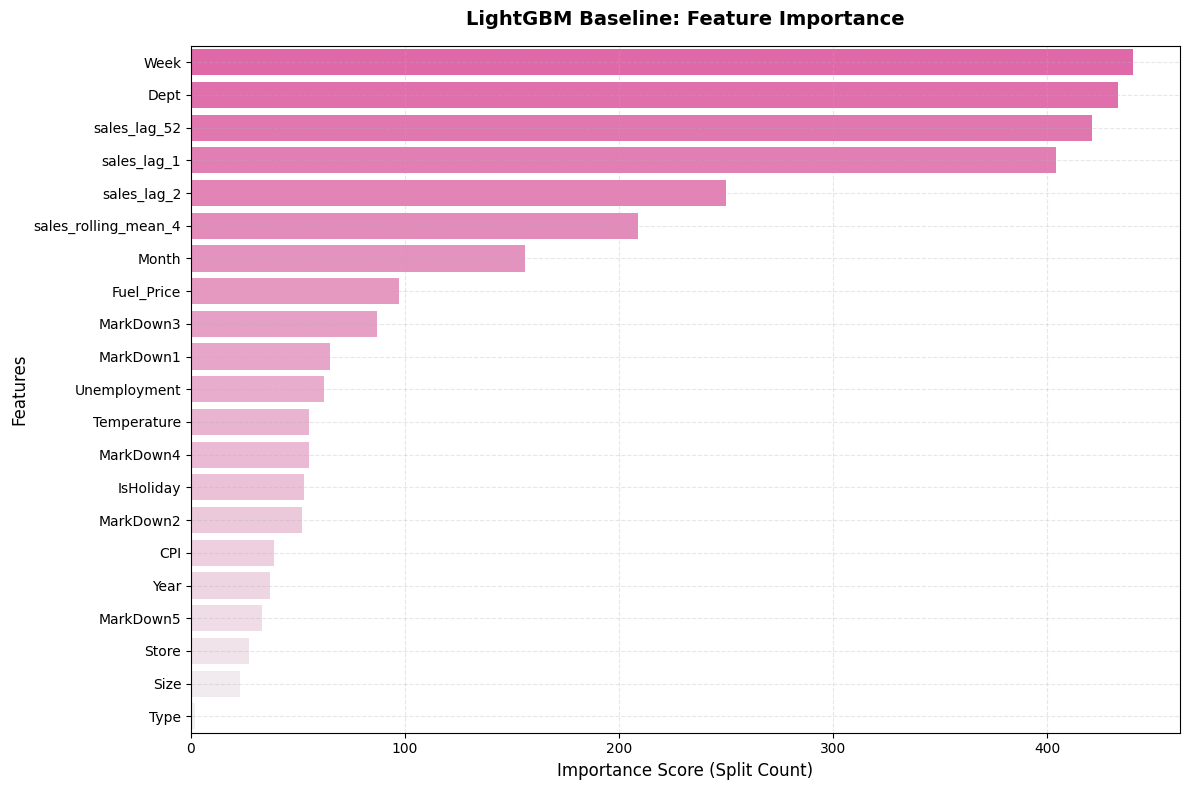

In [15]:
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Value",
    y="Feature",
    data=feature_imp.sort_values(by="Value", ascending=False),
    palette=sns.color_palette("light:#f256a9_r", n_colors=len(feature_imp))
)
plt.title('LightGBM Baseline: Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Split Count)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

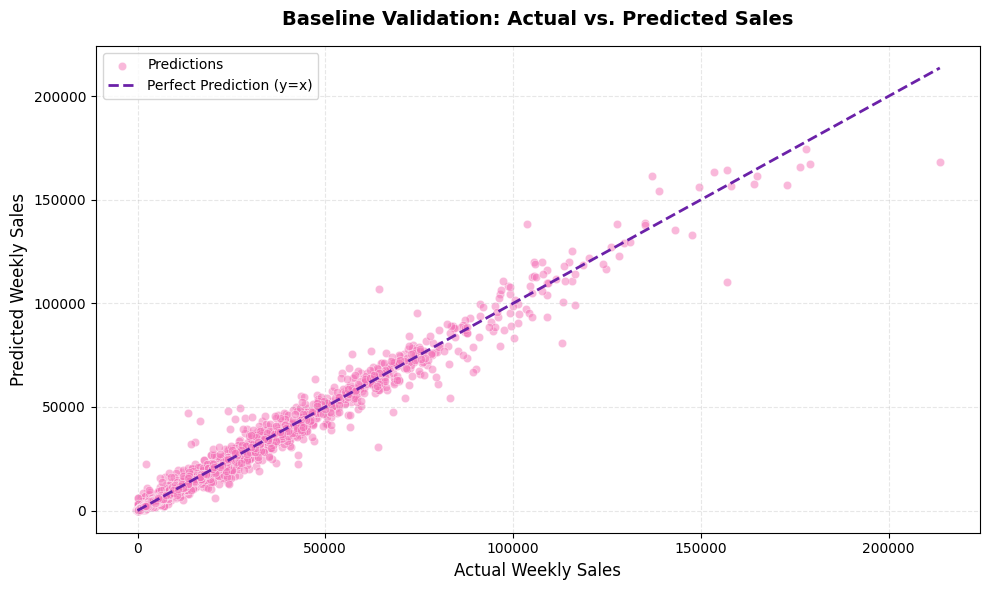

In [16]:
plt.figure(figsize=(10, 6))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#f472b7',
    alpha=0.5,
    label='Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#6b21a8', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Baseline Validation: Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales', fontsize=12)
plt.ylabel('Predicted Weekly Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

 სტრუქტურა სწორია, მაგრამ პიკებს ვერ წვდება ბოლომდე.

In [17]:
with mlflow.start_run(run_name="LGBM_Objective_MAE"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=500,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    mae_obj_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", mae_obj_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

2026/07/08 14:10:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LGBM_Objective_MAE at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/bbf68b3e148841ec8a49afe1c1561031
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


/tmp/ipykernel_977/2415104487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


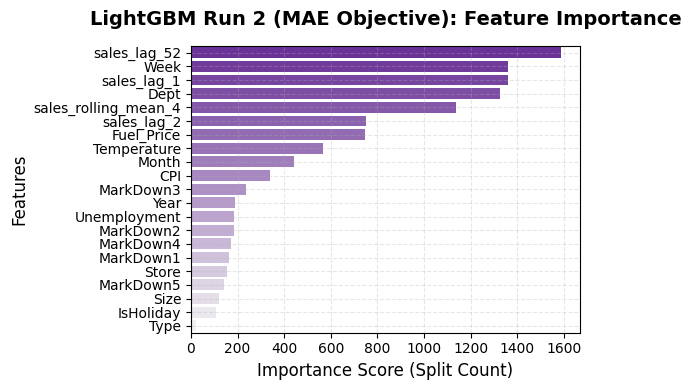

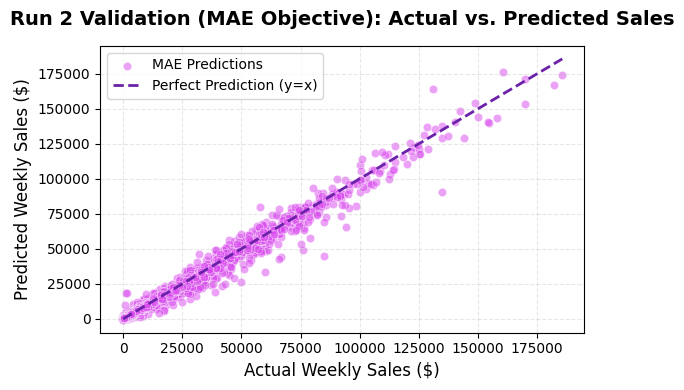

In [18]:
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(6, 4))
sns.barplot(
    x="Value",
    y="Feature",
    data=feature_imp.sort_values(by="Value", ascending=False),
    palette=sns.color_palette("light:#6b21a8_r", n_colors=len(feature_imp))
)
plt.title('LightGBM Run 2 (MAE Objective): Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Split Count)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#d946ef',
    alpha=0.5,
    label='MAE Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#6b21a8', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Run 2 Validation (MAE Objective): Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales ($)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()




მეტი ყურადღება ეთმობა წინა წლის გაყიდვებს, მაგრამ პიკებში მაინც ცდება.



In [19]:
with mlflow.start_run(run_name="LGBM_MAE_LR_0.03"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    lr_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", lr_tuned_wmae)
    mlflow.lightgbm.log_model(model, name="model")

🏃 View run LGBM_MAE_LR_0.03 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/42816ce60a064011b865bcf3f6909ce3
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [20]:
print (lr_tuned_wmae)

1409.8794300612649


es kargia kargia kargiaaa.

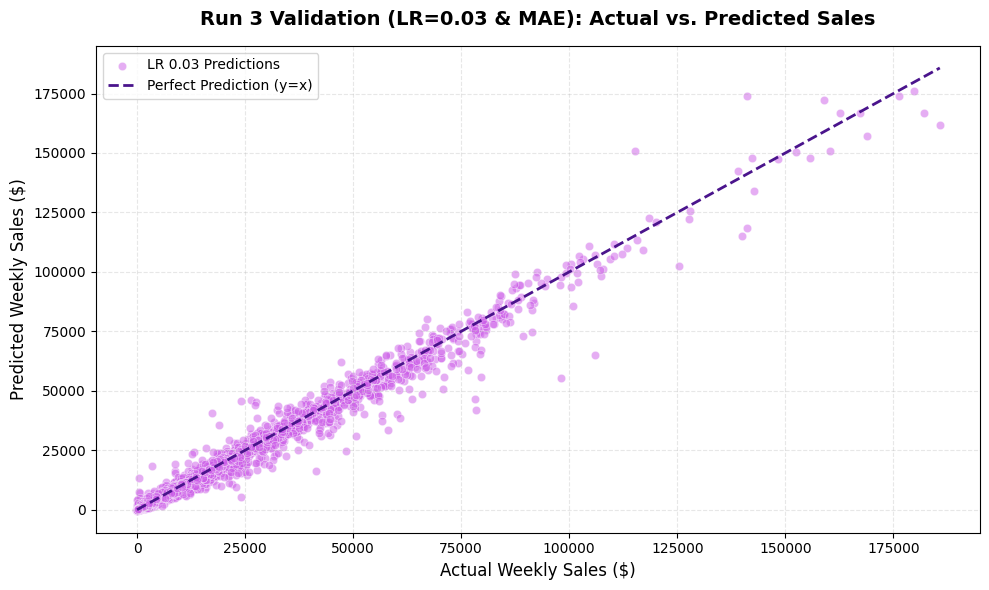

In [21]:
plt.figure(figsize=(10, 6))

indices = np.random.choice(len(y_val), size=5000, replace=False)
val_sample = y_val.iloc[indices] if hasattr(y_val, 'iloc') else y_val[indices]
pred_sample = y_pred[indices]

sns.scatterplot(
    x=val_sample,
    y=pred_sample,
    color='#cc5de8',
    alpha=0.5,
    label='LR 0.03 Predictions'
)

max_val = max(val_sample.max(), pred_sample.max())
plt.plot([0, max_val], [0, max_val], color='#4a148c', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Run 3 Validation (LR=0.03 & MAE): Actual vs. Predicted Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Weekly Sales ($)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

გავზარდოთ

In [22]:
with mlflow.start_run(run_name="LGBM_MAE_Leaves_63"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    leaves_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", leaves_tuned_wmae)
    mlflow.lightgbm.log_model(model, name="model")

🏃 View run LGBM_MAE_Leaves_63 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/6fd4200461df42ff84753e965c8fc0a4
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [23]:
print (leaves_tuned_wmae)

1378.1766504188301


In [24]:

with mlflow.start_run(run_name="LGBM_MAE_Regularized"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    reg_tuned_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", reg_tuned_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(reg_tuned_wmae)

2026/07/08 14:15:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1360.2623633831186
🏃 View run LGBM_MAE_Regularized at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/8ecf595d86cb44aea1b80e4e3cefebf3
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


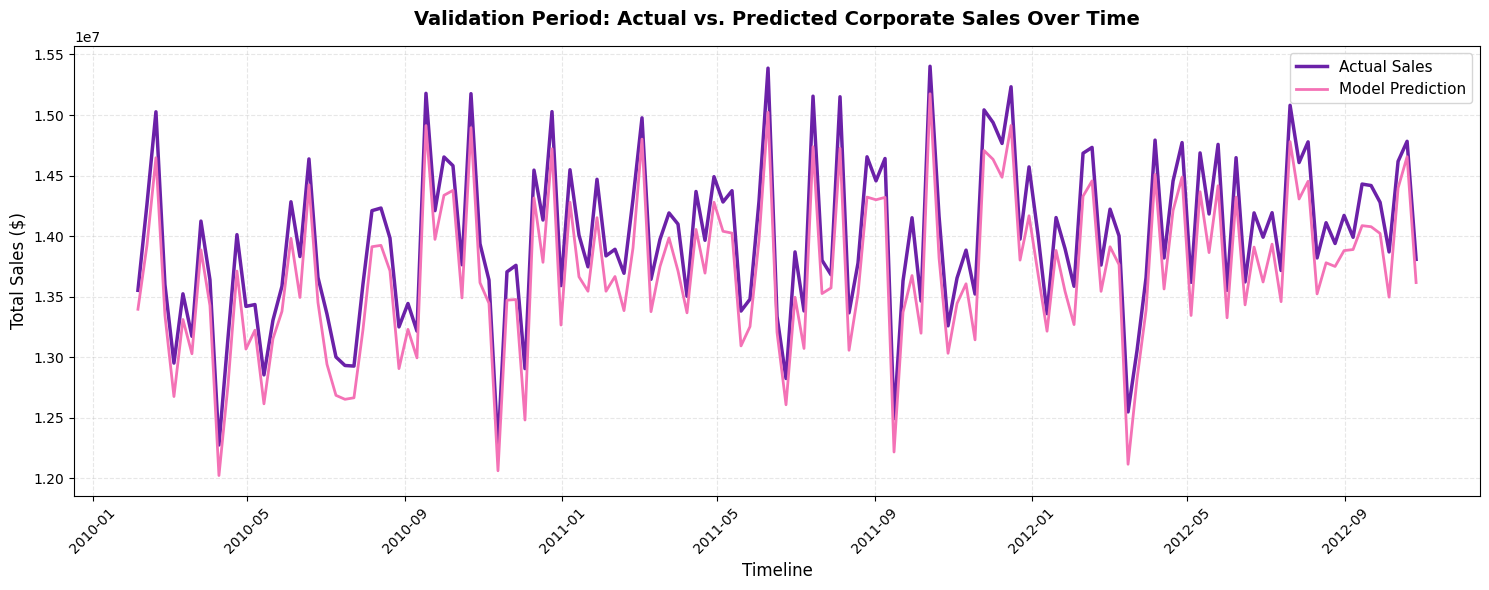

In [25]:
val_timeline = pd.DataFrame({
    'Date': processed_df.loc[X_val.index, 'Date'],
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline['Date'] = pd.to_datetime(val_timeline['Date'])
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(

    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    label='Model Prediction'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

underestimates shvreba sul

In [26]:
def asymmetric_mae_objective(y_true, y_pred):
    residual = y_true - y_pred
    grad = np.where(residual > 0, -1.75, 1.0)
    hess = np.ones_like(y_true)
    return grad, hess

with mlflow.start_run(run_name="LGBM_Asymmetric_MAE"):

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.set_params(objective=asymmetric_mae_objective)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    asym_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", asym_wmae)

    mlflow.lightgbm.log_model(
        model,
        artifact_path="model",
        skops_trusted_types=["__main__.asymmetric_mae_objective"]
    )

    print(asym_wmae)

2026/07/08 14:16:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 14:16:55 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpwtnovh8w/model, flavor: lightgbm). Fall back to return ['lightgbm==4.6.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 


15769.465093497285
🏃 View run LGBM_Asymmetric_MAE at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/6dd928855e5943f3913aae6ad105e648
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


ES RAARI

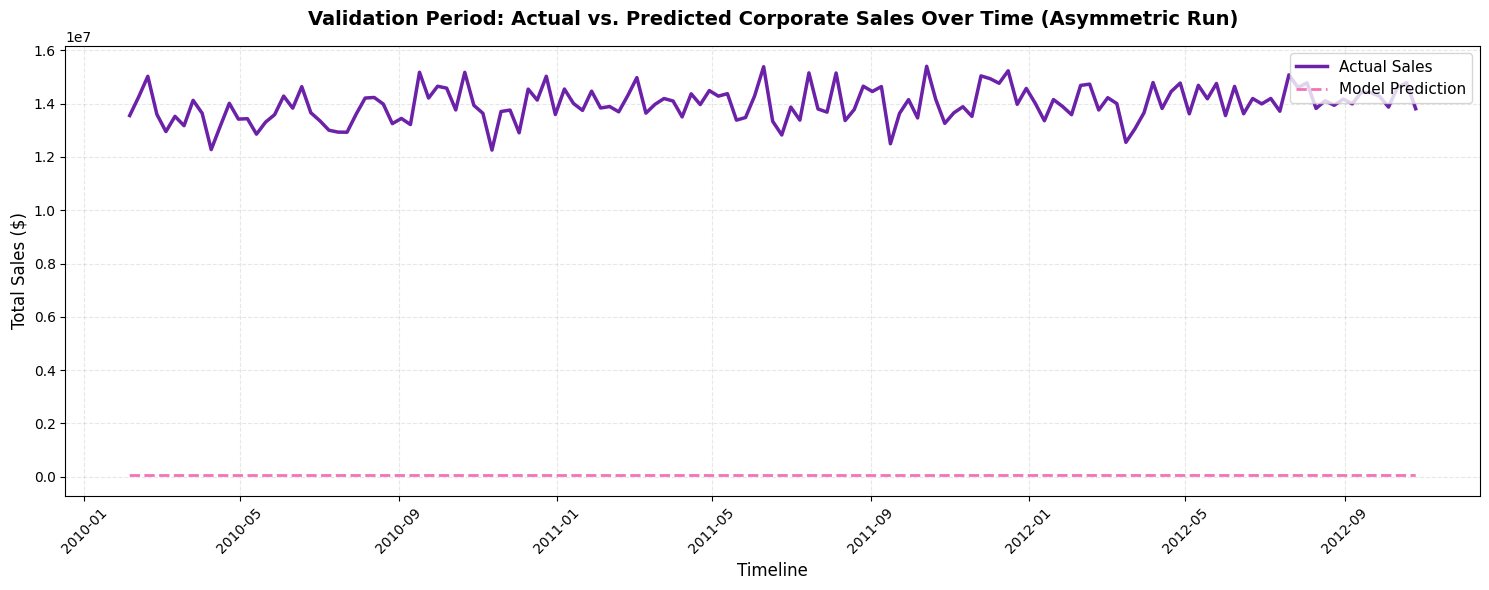

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

val_timeline = pd.DataFrame({
    'Date': processed_df.loc[X_val.index, 'Date'],
    'Actual': y_val,
    'Predicted': y_pred
})

val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline['Date'] = pd.to_datetime(val_timeline['Date'])
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    val_timeline['Date'],
    val_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    val_timeline['Date'],
    val_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Model Prediction'
)

plt.title('Validation Period: Actual vs. Predicted Corporate Sales Over Time (Asymmetric Run)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

?????????

In [28]:
processed_df = processed_df.sort_values('Date').reset_index(drop=True)
processed_df['Date'] = pd.to_datetime(processed_df['Date'])

processed_df['Is_Pre_Holiday'] = processed_df.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
processed_df['Is_Post_Holiday'] = processed_df.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)

train_df = processed_df[processed_df['Date'] < '2011-09-01']
val_df = processed_df[processed_df['Date'] >= '2011-09-01']

drop_cols = ['Weekly_Sales', 'Date', 'Year']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['Weekly_Sales']
X_val = val_df.drop(columns=drop_cols, errors='ignore')
y_val = val_df['Weekly_Sales']

with mlflow.start_run(run_name="LGBM_Holiday_Features"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    holiday_feats_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", holiday_feats_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print (holiday_feats_wmae)

2026/07/08 14:18:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1893.4378960172187
🏃 View run LGBM_Holiday_Features at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/59592fb1bce946678dfc94710786ab11
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


/tmp/ipykernel_977/2772160337.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='Purples_r')


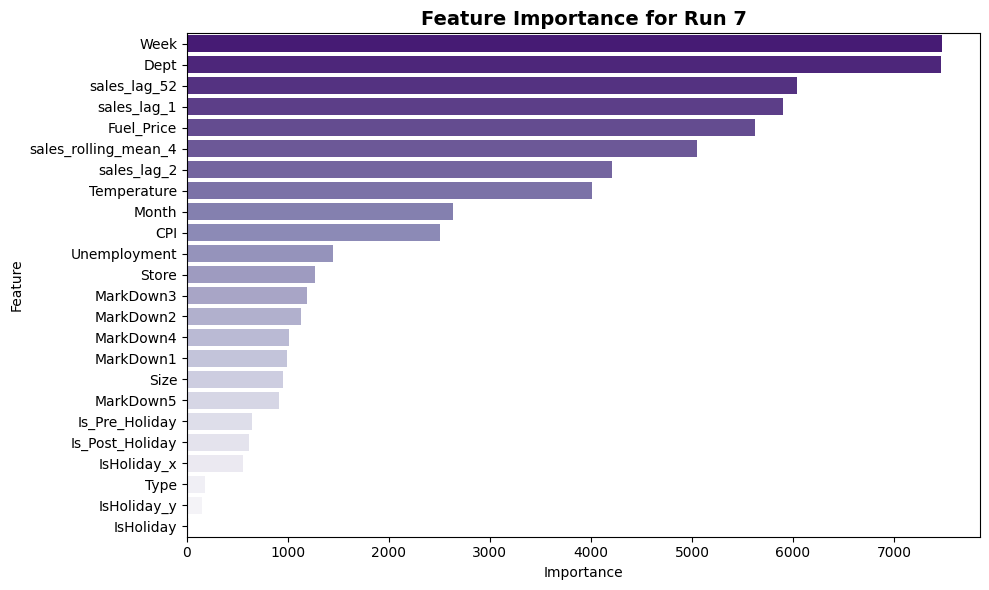

In [29]:

importance = model.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='Purples_r')
plt.title('Feature Importance for Run 7', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



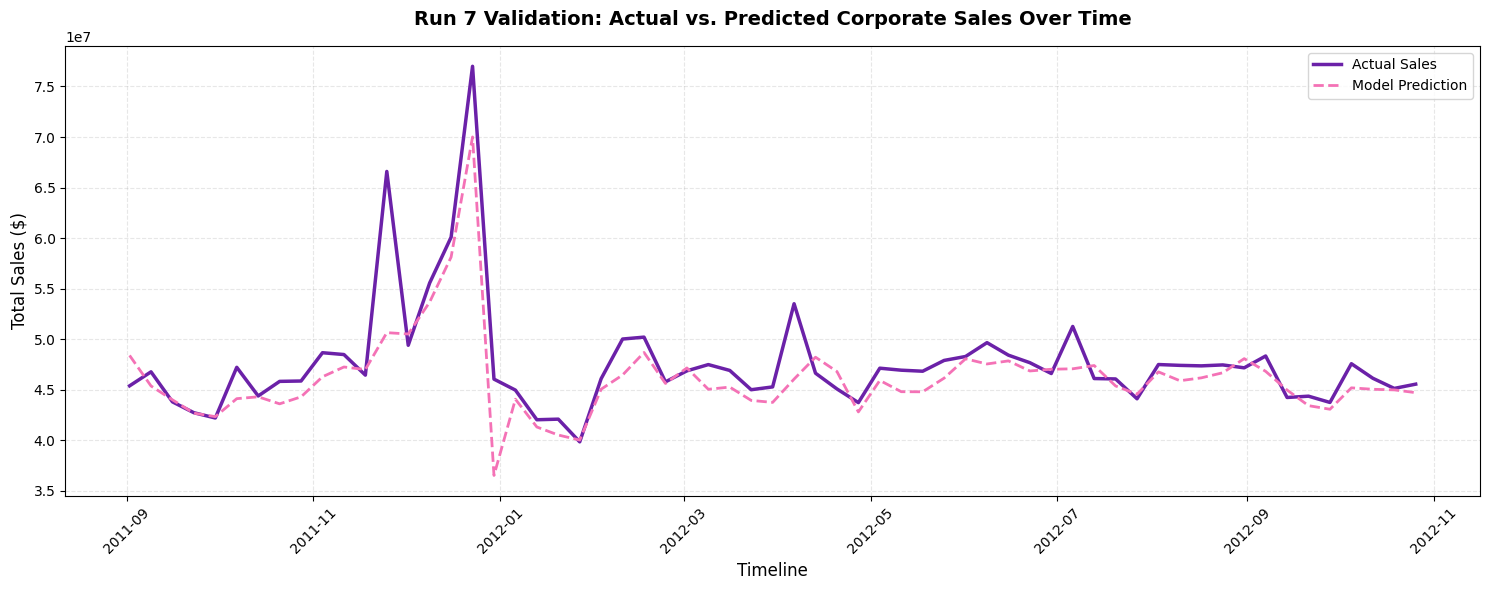

In [30]:
val_timeline = pd.DataFrame({
    'Date': val_df['Date'],
    'Actual': y_val,
    'Predicted': y_pred
})
val_timeline = val_timeline.groupby('Date').sum().reset_index()
val_timeline['Date'] = pd.to_datetime(val_timeline['Date'])
val_timeline = val_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))
plt.plot(val_timeline['Date'], val_timeline['Actual'], color='#6b21a8', linewidth=2.5, label='Actual Sales')
plt.plot(val_timeline['Date'], val_timeline['Predicted'], color='#f472b6', linewidth=2, linestyle='--', label='Model Prediction')
plt.title('Run 7 Validation: Actual vs. Predicted Corporate Sales Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
cols_to_keep = [
    'Date', 'Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_52', 'sales_rolling_mean_4',
    'Fuel_Price', 'Temperature', 'CPI', 'Unemployment', 'Week', 'Month',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]

existing_cols = [col for col in cols_to_keep if col in processed_df.columns]
cleaned_df = processed_df[existing_cols].copy()

cleaned_df = cleaned_df.drop_duplicates(subset=['Date', 'Store', 'Dept'])
cleaned_df = cleaned_df.sort_values('Date').reset_index(drop=True)
cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])

cleaned_df['Is_Pre_Holiday'] = cleaned_df.groupby(['Store', 'Dept'])['IsHoliday'].shift(-1).fillna(0).astype(int)
cleaned_df['Is_Post_Holiday'] = cleaned_df.groupby(['Store', 'Dept'])['IsHoliday'].shift(1).fillna(0).astype(int)
cleaned_df['IsHoliday'] = cleaned_df['IsHoliday'].astype(int)

train_df = cleaned_df[cleaned_df['Date'] < '2011-09-01']
val_df = cleaned_df[cleaned_df['Date'] >= '2011-09-01']

drop_cols = ['Weekly_Sales', 'Date']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['Weekly_Sales']
X_val = val_df.drop(columns=drop_cols, errors='ignore')
y_val = val_df['Weekly_Sales']

if 'Type' in X_train.columns:
    X_train['Type'] = X_train['Type'].astype('category')
    X_val['Type'] = X_val['Type'].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Clean_Holiday_Features"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    clean_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", clean_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(clean_wmae)

2026/07/08 14:19:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1929.79873922259
🏃 View run LGBM_Clean_Holiday_Features at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/b6e20d75b5214eff843c60063d94ded8
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


ვაიმე

In [32]:
base_features = [
    'Store', 'Dept', 'IsHoliday', 'Size', 'Week', 'Month',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_52', 'sales_rolling_mean_4'
]

available_features = [col for col in base_features if col in processed_df.columns]

if 'Date' in processed_df.columns:
    df_simple = processed_df[['Date', 'Weekly_Sales'] + available_features].copy()
else:
    df_simple = processed_df[['Weekly_Sales'] + available_features].copy()
    df_simple['Date'] = train_df['Date'] if 'train_df' in locals() else processed_df.index

df_simple = df_simple.drop_duplicates(subset=['Date', 'Store', 'Dept'])
df_simple['Date'] = pd.to_datetime(df_simple['Date'])
df_simple = df_simple.sort_values('Date').reset_index(drop=True)

train_df = df_simple[df_simple['Date'] < '2011-09-01']
val_df = df_simple[df_simple['Date'] >= '2011-09-01']

X_train = train_df[available_features].copy()
y_train = train_df['Weekly_Sales']
X_val = val_df[available_features].copy()
y_val = val_df['Weekly_Sales']

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = X_train[col].astype('category')
        X_val[col] = X_val[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Reset_Safe_Baseline"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_pred = model.predict(X_val)

    weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    absolute_errors = np.abs(y_val - y_pred)
    reset_wmae = np.sum(weights * absolute_errors) / np.sum(weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_val", reset_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(reset_wmae)


2026/07/08 14:20:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1822.544126568599
🏃 View run LGBM_Reset_Safe_Baseline at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/ea484b62d0e04ed6ba9889a9b72d5c04
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


თავიდან მთლიანად


In [33]:

train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

In [34]:
transformer = WalmartDataTransformer(features_df=features_df, stores_df=stores_df)
processed_df = transformer.transform(train_df)

In [35]:
splitter = TimeSeriesSplitter(split_date='2012-01-01')

X_train, y_train, X_val, y_val = splitter.split(processed_df)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")


Train: (294132, 21), Validation: (127438, 21)


trains davulogav wina sauketesosac


In [36]:
X_train, y_train, X_val, y_val = splitter.split(processed_df)

features_to_use = [col for col in X_train.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = X_train[features_to_use].copy()
X_val_final = X_val[features_to_use].copy()

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_MAE_Regularized_Logged"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print(f"Train WMAE: {train_wmae:.2f}")
    print(f"Validation WMAE: {val_wmae:.2f}")

2026/07/08 14:22:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train WMAE: 1599.68
Validation WMAE: 1358.49
🏃 View run LGBM_MAE_Regularized_Logged at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/6c5a511780fe48e3a34c7a991636346a
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


monacemebs aghar vaxleb xels

In [38]:
X_train, y_train, X_val, y_val = splitter.split(processed_df)

features_to_use = [col for col in X_train.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = X_train[features_to_use].copy()
X_val_final = X_val[features_to_use].copy()

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')


with mlflow.start_run(run_name="LGBM_Deep_Trees_Tuned"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=10,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print("train " + str(train_wmae))
    print("val " + str(val_wmae))

train 1359.119578917033
val 1334.0411395343344
🏃 View run suave-mouse-428 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/34c6a7e010184ed7b86b80bccaa538fb
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [39]:
X_train, y_train, X_val, y_val = splitter.split(processed_df)

features_to_use = [col for col in X_train.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = X_train[features_to_use].copy()
X_val_final = X_val[features_to_use].copy()

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Deep_Trees_Regularized"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=10,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=5.0,            #l1
        reg_lambda=5.0,           #l1
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, artifact_path="model")

    print("train " + str(train_wmae))
    print("val " + str(val_wmae))

2026/07/08 14:33:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train 1361.4892451793569
val 1327.7459386327093
🏃 View run LGBM_Deep_Trees_Regularized at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/4b2a5376a556420391eadcbef0d7cbf2
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


In [40]:
X_train, y_train, X_val, y_val = splitter.split(processed_df)

features_to_use = [col for col in X_train.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = X_train[features_to_use].copy()
X_val_final = X_val[features_to_use].copy()

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_Max_Capacity_Trees"):

    model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=2000,        #early stopping mainc sheacherebs
        learning_rate=0.03,
        num_leaves=255,
        min_data_in_leaf=10,
        feature_fraction=0.75,     #sxvadasxva featurebistvis
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=10.0,           #+regularizacia
        reg_lambda=10.0,          #aqac
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_final, y_train,
        eval_set=[(X_val_final, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    y_train_pred = model.predict(X_train_final)
    train_weights = X_train['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

    y_val_pred = model.predict(X_val_final)
    val_weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
    val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

    mlflow.log_params(model.get_params())
    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)
    mlflow.lightgbm.log_model(model, name="model")

    print("train " + str(train_wmae))
    print("val " + str(val_wmae))

train 1347.865788508731
val 1333.3399067922182
🏃 View run LGBM_Max_Capacity_Trees at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/7fa7d35ac56b4943a016b8b39f35601c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


მორჩა, ამის მერე ისევ უკან წავა. წინას შევინახავ




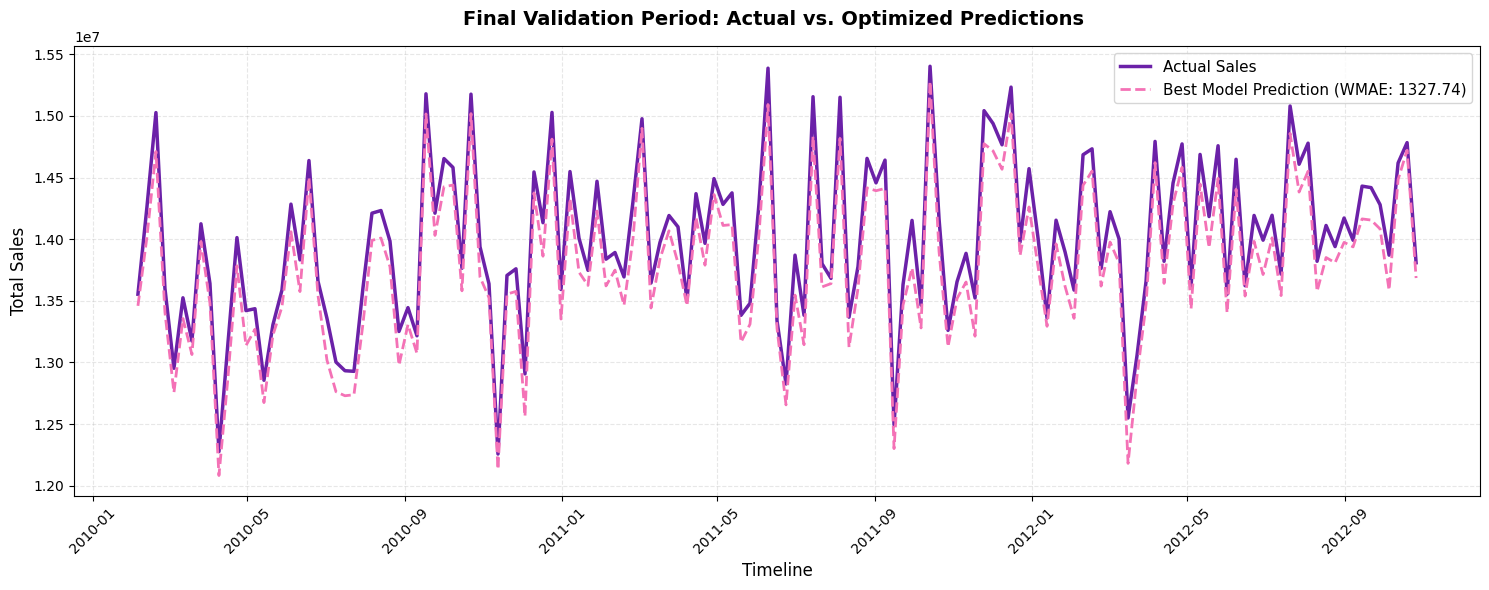

In [41]:

best_model = lgb.LGBMRegressor(
        objective='mae',
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=127,
        min_data_in_leaf=10,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=5.0,            #l1
        reg_lambda=5.0,           #l1
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

best_model.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
)

y_val_pred_best = best_model.predict(X_val_final)

val_dates = processed_df.loc[X_val.index, 'Date']

final_timeline = pd.DataFrame({
    'Date': val_dates,
    'Actual': y_val,
    'Predicted': y_val_pred_best
})

final_timeline = final_timeline.groupby('Date').sum().reset_index()
final_timeline['Date'] = pd.to_datetime(final_timeline['Date'])
final_timeline = final_timeline.sort_values('Date')

plt.figure(figsize=(15, 6))

plt.plot(
    final_timeline['Date'],
    final_timeline['Actual'],
    color='#6b21a8',
    linewidth=2.5,
    label='Actual Sales'
)

plt.plot(
    final_timeline['Date'],
    final_timeline['Predicted'],
    color='#f472b6',
    linewidth=2,
    linestyle='--',
    label='Best Model Prediction (WMAE: 1327.74)'
)

plt.title('Final Validation Period: Actual vs. Optimized Predictions ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
with mlflow.start_run(run_name="LGBM_Champion_Final_Save") as run:

    mlflow.log_params(best_model.get_params())

    mlflow.log_metric("wmae_train", train_wmae)
    mlflow.log_metric("wmae_val", val_wmae)

    mlflow.lightgbm.log_model(
        lgb_model=best_model,
        artifact_path="walmart_lgbm_model"
    )

    run_id = run.info.run_id
    print("შეინახა მოდელი")
    print(f"Run ID: {run_id}")
    print(f"მოდელის URI: 'runs_uri' = 'runs:/{run_id}/walmart_lgbm_model'")

2026/07/08 14:39:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


შეინახა მოდელი
Run ID: 9ac03e08338a4ab5836450d3bfa6e1d9
მოდელის URI: 'runs_uri' = 'runs:/9ac03e08338a4ab5836450d3bfa6e1d9/walmart_lgbm_model'
🏃 View run LGBM_Champion_Final_Save at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/9ac03e08338a4ab5836450d3bfa6e1d9
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2


shemesala

In [43]:

X_train, y_train, X_val, y_val = splitter.split(processed_df)
features_to_use = [col for col in X_train.columns if col not in ['Date', 'Weekly_Sales', 'Year']]

X_train_final = X_train[features_to_use].copy()
X_val_final = X_val[features_to_use].copy()

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')
        X_val_final[col] = X_val_final[col].astype('category')

real_best_model = lgb.LGBMRegressor(
    objective='mae',
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=127,
    min_data_in_leaf=10,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=5.0,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

real_best_model.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
)

y_train_pred = real_best_model.predict(X_train_final)
train_weights = X_train['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
correct_train_wmae = np.sum(train_weights * np.abs(y_train - y_train_pred)) / np.sum(train_weights)

y_val_pred = real_best_model.predict(X_val_final)
val_weights = X_val['IsHoliday'].apply(lambda x: 5 if x in [1, True, '1'] else 1).values
correct_val_wmae = np.sum(val_weights * np.abs(y_val - y_val_pred)) / np.sum(val_weights)

mlflow.set_experiment("Walmart_LightGBM_Forecasting")

with mlflow.start_run(run_name="LGBM_True_Champion_Upload") as run:

    mlflow.log_params(real_best_model.get_params())
    mlflow.log_metric("wmae_train", correct_train_wmae)
    mlflow.log_metric("wmae_val", correct_val_wmae)

    mlflow.lightgbm.log_model(
        lgb_model=real_best_model,
        artifact_path="walmart_champion_lgbm_model"
    )

    print("სწორი მოდელი აიტვირთა")
    print(f"Train WMAE: {correct_train_wmae:.2f}")
    print(f"Validation WMAE (უნდა იყოს 1327.74): {correct_val_wmae:.2f}")
    print(f"Run ID : {run.info.run_id}")

2026/07/08 14:42:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


სწორი მოდელი აიტვირთა
Train WMAE: 1361.49
Validation WMAE (უნდა იყოს 1327.74): 1327.75
Run ID : 28546ad4316e45ee9f275c4eb7e61f0c
🏃 View run LGBM_True_Champion_Upload at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2/runs/28546ad4316e45ee9f275c4eb7e61f0c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/2
